# Analiza podatkov za VNL 2026

V tem zvezku analiziram podatke o igralcih in igralkah Volleyball Nations League - VNL 2026 (moška in ženska liga), ki sem jih zbrala s spletne strani volleyballworld.com.

Analiza vsebuje:
1. Nalaganje in čiščenje podatkov
2. Primerjavo po državah/ekipah
3. Primerjavo moški vs. ženske
4. Porazdelitev igralcev po pozicijah



## Priprava

### Uvoz knjižnic

- **pandas** - knjižnica za delo s tabelami podatkov (podobno Excelu, ampak v Pythonu)
- **matplotlib** - knjižnica za risanje grafov

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

### Nalaganje podatkov

In [19]:
moski = pd.read_csv("igralci_moski.csv")
zenske = pd.read_csv("igralci_zenske.csv")

moski["spol"] = "M"
zenske["spol"] = "Ž"

igralci = pd.concat([moski, zenske], ignore_index=True)

### Čiščenje podatkov

Popravila bom tri vrste stolpcev:
1. **visina_cm**  (besedilo kot `"175cm"`) - odstranila bom `"cm"` in pretvorila string v število.
2. **Odstotkovni stolpci** (`ucinkovitost_napad`, `uspesnost_blok`, `uspesnost_servis`) (besedilo kot `"50.00%"`) - odstranila bom `"%"` in pretvorila v število.
3. **Ostali številčni stolpci** - nekateri igralci imajo namesto števila zapisan pomišljaj `"-"` (če še niso odigrali nobene tekme). `pd.to_numeric(..., errors="coerce")` tak primer spremeni v `NaN` (manjkajoča vrednost).

In [ ]:
igralci["visina_cm"] = igralci["visina_cm"].str.replace("cm", "")
igralci["visina_cm"] = pd.to_numeric(igralci["visina_cm"], errors="coerce")


stolpci_odstotki = ["ucinkovitost_napad", "uspesnost_blok", "uspesnost_servis"]
for stolpec in stolpci_odstotki:
    igralci[stolpec] = igralci[stolpec].astype(str).str.replace("%", "")
    igralci[stolpec] = pd.to_numeric(igralci[stolpec], errors="coerce")


stolpci_stevilke = [
    "starost", "tocke_skupaj", "tocke_povprecje", "tocke_napad", "napad_povprecje",
    "tocke_blok", "blok_povprecje", "tocke_servis", "servis_povprecje",
]


for stolpec in stolpci_stevilke:
    igralci[stolpec] = pd.to_numeric(igralci[stolpec], errors="coerce")

## Povprečna starost in višina (moški, ženske, primerjava)

Najprej si poglejmo povprečno starost in višino pri moških, urejeno po višini (padajoče).

In [42]:
moski_starost = (
    igralci[igralci["spol"] == "M"]
    .groupby("drzava")[["starost", "visina_cm"]]
    .mean()
    .round(1)
    .sort_values(by="visina_cm", ascending=False)
)

moski_starost_tabela = moski_starost.reset_index()
moski_starost_tabela.index += 1
moski_starost_tabela.columns = ["Država", "Povpr. starost", "Povpr. višina"]
moski_starost_tabela

,Država,Povpr. starost,Povpr. višina
1,Turčija,26.1,199.8
2,Poljska,28.2,199.3
3,ZDA,28.7,198.7
4,Slovenija,25.9,198.5
5,Srbija,25.7,197.9
6,Kuba,27.2,197.8
7,Brazilija,27.3,197.5
8,Iran,22.9,197.4
9,Ukrajina,28.3,197.0
10,Kitajska,26.0,196.8


Opazimo lahko (nepresenetljivo), da so v povprečju najnižji Japonci. Vidimo lahko tudi, da so Slovenci zelo visoko na lestvici.


Poglejmo si enako tabelo še za ženske.

In [43]:
zenske_starost = (
    igralci[igralci["spol"] == "Ž"]
    .groupby("drzava")[["starost", "visina_cm"]]
    .mean()
    .round(1)
    .sort_values(by="visina_cm", ascending=False)
)

zenske_starost_tabela = zenske_starost.reset_index()
zenske_starost_tabela.index += 1
zenske_starost_tabela.columns = ["Država", "Povpr. starost", "Povpr. višina"]
zenske_starost_tabela

,Država,Povpr. starost,Povpr. višina
1,Kitajska,22.8,186.9
2,Dominikanska republika,26.7,186.7
3,Turčija,24.8,186.4
4,Brazilija,27.4,186.2
5,Nizozemska,24.4,186.1
6,ZDA,27.7,185.9
7,Nemčija,24.1,185.8
8,Srbija,25.1,185.1
9,Poljska,25.8,184.8
10,Italija,26.3,184.6


Tu lahko opazimo zelo zanimivo nasprotje - vidimo, da so v povprečju najvišje Kitajke, ki na splošno ne veljajo za najvišje. Preostali dve azijski ekipi sta pričakovano na zadnjih dveh mestih.


Poglejmo si še primerjavo po povprečni starosti med moškimi in ženskami (za tiste ekipe, kjer država nastopa tako pri moških kot pri ženskah).

In [53]:
primerjava_starosti = (
    igralci.groupby(["drzava", "spol"])["starost"]
    .mean()
    .round(1)
    .unstack()
    .dropna()
)

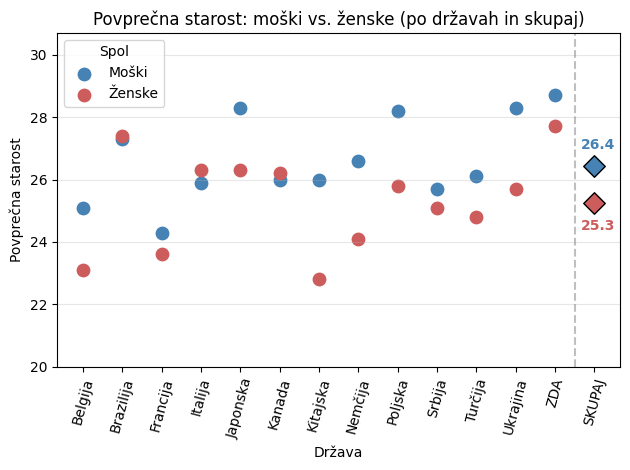

In [75]:
x = range(len(primerjava_starosti))

povprecje_vsi = igralci.groupby("spol")["starost"].mean()

plt.scatter(x, primerjava_starosti.iloc[:, 0], color="steelblue", label="Moški", s=80)
plt.scatter(x, primerjava_starosti.iloc[:, 1], color="indianred", label="Ženske", s=80)

x_skupaj = len(primerjava_starosti)

plt.scatter(x_skupaj, povprecje_vsi["M"], color="steelblue", marker="D", s=120, edgecolor="black")
plt.scatter(x_skupaj, povprecje_vsi["Ž"], color="indianred", marker="D", s=120, edgecolor="black")

plt.annotate(
    f"{povprecje_vsi['M']:.1f}",           
    (x_skupaj, povprecje_vsi["M"]),        
    xytext=(-10, 15),                        
    textcoords="offset points",           
    va="center",                           
    fontweight="bold",
    color="steelblue",
)
plt.annotate(
    f"{povprecje_vsi['Ž']:.1f}",
    (x_skupaj, povprecje_vsi["Ž"]),
    xytext=(-10, -17),
    textcoords="offset points",
    va="center",
    fontweight="bold",
    color="indianred",
)

plt.axvline(x_skupaj - 0.5, color="gray", linestyle="--", alpha=0.5)

imena_x = list(primerjava_starosti.index) + ["SKUPAJ"]
plt.xticks(list(x) + [x_skupaj], imena_x, rotation=75)

plt.ylim(20, max(primerjava_starosti.max().max(), povprecje_vsi.max()) + 2)
plt.title("Povprečna starost: moški vs. ženske (po državah in skupaj)")
plt.xlabel("Država")
plt.ylabel("Povprečna starost")
plt.legend(title="Spol")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Iz grafa lahko jasno vidimo, da je v večini povprečna starost moške reprezentance višja od povprečne starosti ženske reprezentance. To dokažeta tudi romba na koncu grafa, ki prikazujeta povprečno starost moških in žensk za VSE države skupaj.